<a href="https://colab.research.google.com/github/Aditya-Barua/CSE440Project_21101004/blob/main/CSE440Project_21101004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).





# BASIC EDA & DATA PREPROCESSING

In [17]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/CSE440/POS DATASET 2/Dataset_B_POS_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/CSE440/POS DATASET 2/Dataset_B_POS_test.csv')

print("Training Data Sample:")
print(train_df.head())

print("\nTesting Data Sample:")
print(test_df.head())

print(f"\nTraining set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training Data Sample:
   Sentence #                                           Sentence  \
0           1  Yemen 's official news agency reports Sunday t...   
1           2  In other news , a suicide bomb attack in north...   
2           3  A Lion had come to the end of his days and lay...   
3           4  The case involves the leak of the identity of ...   
4           5  The statement quoted Mr. Yushchenko as telling...   

                                                 POS  
0  ['NNP', 'POS', 'JJ', 'NN', 'NN', 'VBZ', 'NNP',...  
1  ['IN', 'JJ', 'NN', ',', 'DT', 'NN', 'NN', 'NN'...  
2  ['DT', 'NN', 'VBD', 'VBN', 'TO', 'DT', 'NN', '...  
3  ['DT', 'NN', 'VBZ', 'DT', 'NN', 'IN', 'DT', 'N...  
4  ['DT', 'NN', 'VBD', 'NNP', 'NNP', 'IN', 'VBG',...  

Testing Data Sample:
   Sentence #                                           Sentence  \
0           1  This remarkable achievement has been reflected...   
1           2  With the addition of the midwestern state of I...   
2           3

In [18]:
print("Training Data Structure:")
print(train_df.info())

print("\nMissing Values in Training Data:")
print(train_df.isnull().sum())

print("\nDuplicate Rows in Training Data:")
print(train_df.duplicated().sum())

print("\nTesting Data Structure:")
print(test_df.info())

print("\nMissing Values in Testing Data:")
print(test_df.isnull().sum())

print("\nDuplicate Rows in Testing Data:")
print(test_df.duplicated().sum())


Training Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19184 entries, 0 to 19183
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence #  19184 non-null  int64 
 1   Sentence    19184 non-null  object
 2   POS         19184 non-null  object
dtypes: int64(1), object(2)
memory usage: 449.8+ KB
None

Missing Values in Training Data:
Sentence #    0
Sentence      0
POS           0
dtype: int64

Duplicate Rows in Training Data:
0

Testing Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4796 entries, 0 to 4795
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence #  4796 non-null   int64 
 1   Sentence    4796 non-null   object
 2   POS         4796 non-null   object
dtypes: int64(1), object(2)
memory usage: 112.5+ KB
None

Missing Values in Testing Data:
Sentence #    0
Sentence      0
POS           0
dtype: int


 First few rows of the training dataset:
   Sentence #                                           Sentence  \
0           1  Yemen 's official news agency reports Sunday t...   
1           2  In other news , a suicide bomb attack in north...   
2           3  A Lion had come to the end of his days and lay...   
3           4  The case involves the leak of the identity of ...   
4           5  The statement quoted Mr. Yushchenko as telling...   

                                                 POS  
0  ['NNP', 'POS', 'JJ', 'NN', 'NN', 'VBZ', 'NNP',...  
1  ['IN', 'JJ', 'NN', ',', 'DT', 'NN', 'NN', 'NN'...  
2  ['DT', 'NN', 'VBD', 'VBN', 'TO', 'DT', 'NN', '...  
3  ['DT', 'NN', 'VBZ', 'DT', 'NN', 'IN', 'DT', 'N...  
4  ['DT', 'NN', 'VBD', 'NNP', 'NNP', 'IN', 'VBG',...  


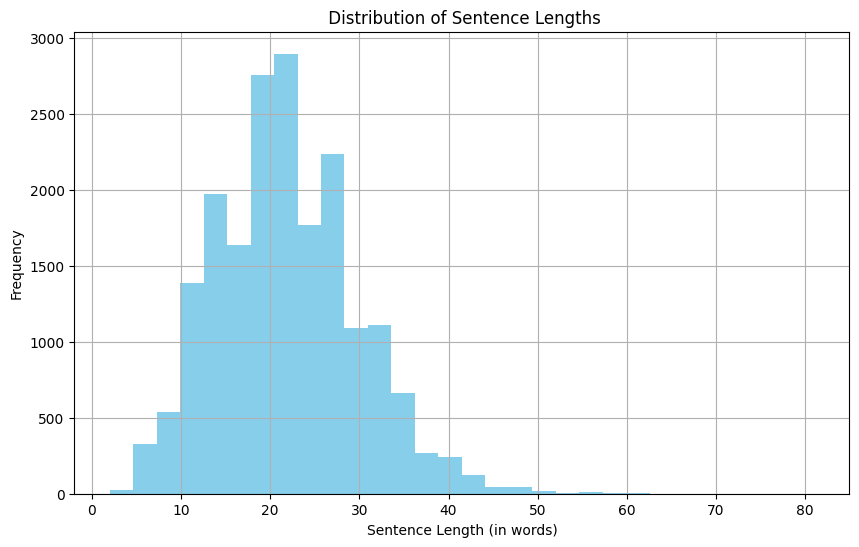


 Sentence Length Summary Statistics:
count    19184.000000
mean        21.855557
std          7.945111
min          2.000000
25%         16.000000
50%         21.000000
75%         27.000000
max         81.000000
Name: sentence_length, dtype: float64


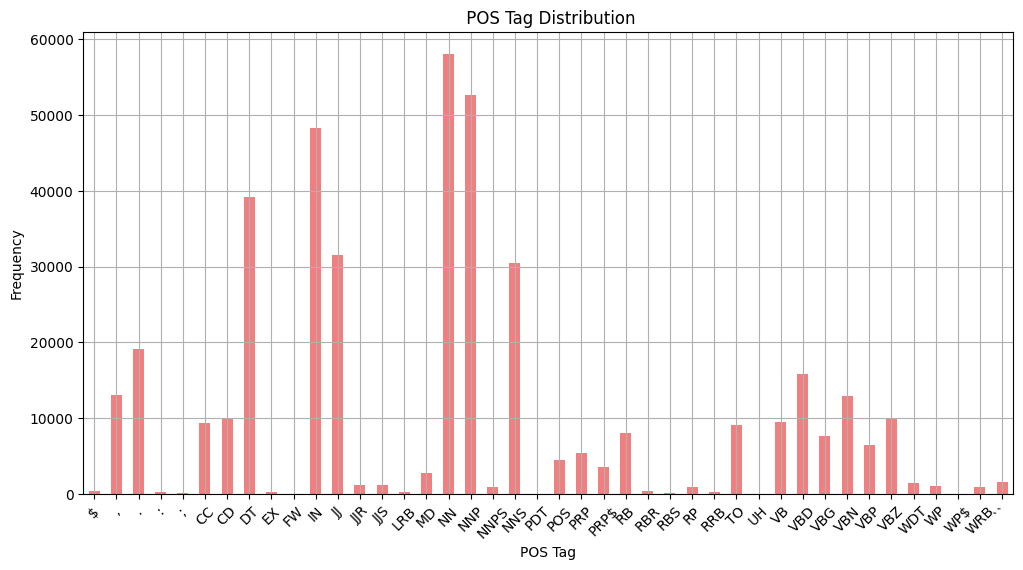


 Top 10 POS Tags:
$         454
,       13106
.       19134
:         294
;          78
CC       9370
CD       9986
DT      39156
EX        261
FW          1
IN      48353
JJ      31555
JJR      1248
JJS      1239
LRB       286
MD       2791
NN      58053
NNP     52681
NNPS      990
NNS     30422
Name: count, dtype: int64


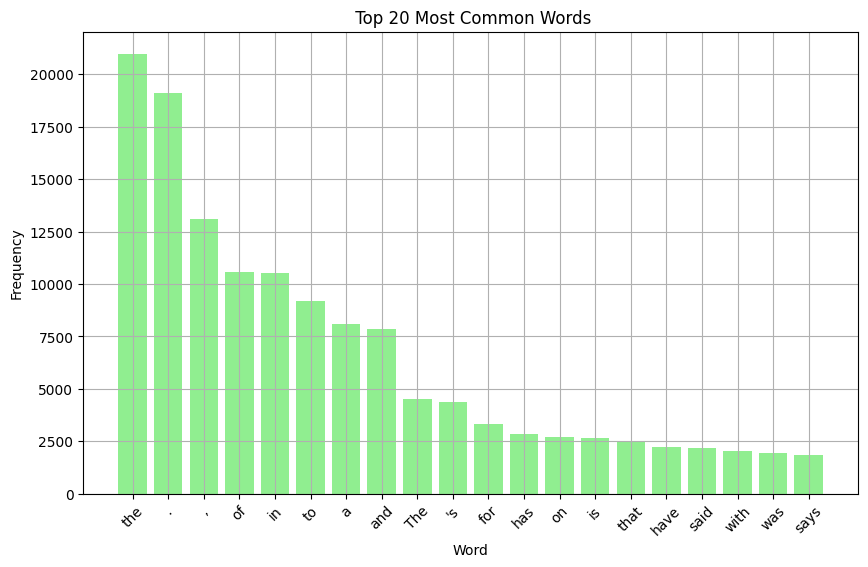


 Sample Sentences and Corresponding POS Tags:
Sentence: Yemen 's official news agency reports Sunday that rescue efforts continue but that many people are still missing and feared to have drowned .
POS Tags: ['NNP', 'POS', 'JJ', 'NN', 'NN', 'VBZ', 'NNP', 'IN', 'NN', 'NNS', 'VBP', 'CC', 'IN', 'JJ', 'NNS', 'VBP', 'RB', 'VBG', 'CC', 'VBN', 'TO', 'VB', 'VBN', '.']

Sentence: In other news , a suicide bomb attack in northwestern Pakistan has killed at least four Pakistani soldiers in a military convoy .
POS Tags: ['IN', 'JJ', 'NN', ',', 'DT', 'NN', 'NN', 'NN', 'IN', 'JJ', 'NNP', 'VBZ', 'VBN', 'IN', 'JJS', 'CD', 'JJ', 'NNS', 'IN', 'DT', 'JJ', 'NN', '.']

Sentence: A Lion had come to the end of his days and lay sick unto death at the mouth of his cave , gasping for breath .
POS Tags: ['DT', 'NN', 'VBD', 'VBN', 'TO', 'DT', 'NN', 'IN', 'PRP$', 'NNS', 'CC', 'VB', 'JJ', 'JJ', 'NN', 'IN', 'DT', 'NN', 'IN', 'PRP$', 'NN', ',', 'VBG', 'IN', 'NN', '.']

Sentence: The case involves the leak of the ide

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("\n First few rows of the training dataset:")
print(train_df.head())


train_df['sentence_length'] = train_df['Sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
train_df['sentence_length'].hist(bins=30, color='skyblue')
plt.title(' Distribution of Sentence Lengths')
plt.xlabel('Sentence Length (in words)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\n Sentence Length Summary Statistics:")
print(train_df['sentence_length'].describe())

train_df['POS'] = train_df['POS'].apply(lambda x: eval(x) if isinstance(x, str) else x)
pos_tags = [tag for tags in train_df['POS'] for tag in tags]
pos_tag_counts = pd.Series(pos_tags).value_counts()
pos_tag_counts = pos_tag_counts.sort_index()

plt.figure(figsize=(12, 6))
pos_tag_counts.plot(kind='bar', color='lightcoral')
plt.title(' POS Tag Distribution')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print("\n Top 10 POS Tags:")
print(pos_tag_counts.head(20))

word_tokens = [word for sentence in train_df['Sentence'] for word in sentence.split()]
word_counts = Counter(word_tokens)
most_common_words = word_counts.most_common(20)

words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='lightgreen')
plt.title(' Top 20 Most Common Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print("\n Sample Sentences and Corresponding POS Tags:")
for i in range(5):
    print(f"Sentence: {train_df.iloc[i]['Sentence']}")
    print(f"POS Tags: {train_df.iloc[i]['POS']}\n")


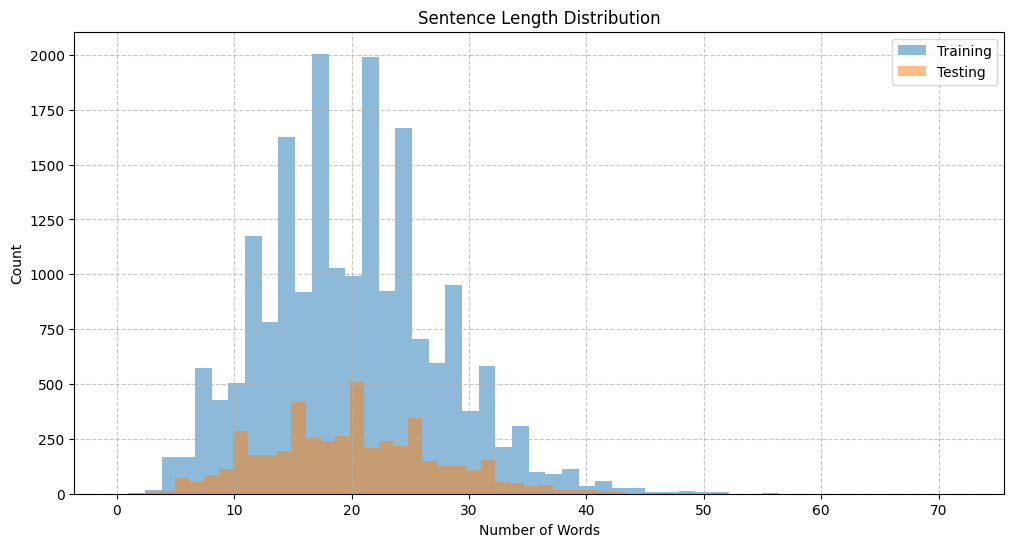

Average sentence length (train): 20.05 words
Average sentence length (test): 20.09 words
Maximum sentence length (train): 72 words
Maximum sentence length (test): 62 words


In [79]:
train_sent_lengths = [len(s) for s in train_sentences]
test_sent_lengths = [len(s) for s in test_sentences]

plt.figure(figsize=(12, 6))
plt.hist(train_sent_lengths, bins=50, alpha=0.5, label='Training')
plt.hist(test_sent_lengths, bins=50, alpha=0.5, label='Testing')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Average sentence length (train): {np.mean(train_sent_lengths):.2f} words")
print(f"Average sentence length (test): {np.mean(test_sent_lengths):.2f} words")
print(f"Maximum sentence length (train): {max(train_sent_lengths)} words")
print(f"Maximum sentence length (test): {max(test_sent_lengths)} words")

In [81]:
max_len = max(max(len(s) for s in X_train_seq),
              max(len(s) for s in X_test_seq))

print(f"Maximum sequence length: {max_len}")

Maximum sequence length: 72


In [20]:
import nltk
from nltk.tokenize import word_tokenize
import string
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

nltk.download('punkt')
nltk.download('punkt_tab')
def preprocess_data(df):
    clean_sentences = []
    clean_tags = []

    for _, row in df.iterrows():
        sentence = row['Sentence']
        tags_str = row['POS']
        if not isinstance(tags_str, str):
            try:
                tags_str = str(tags_str)
            except:
                print(f"Skipping row due to invalid POS format: {tags_str}")
                continue

        tags = eval(tags_str)

        tokens = word_tokenize(sentence)
        filtered_tokens = []
        filtered_tags = []

        punctuation_pos_tags = ['``', "''", '.', ',', ':', ';', '--', '-', '(', ')', '$', '#']

        for token, tag in zip(tokens, tags):
            if tag not in punctuation_pos_tags:
                filtered_tokens.append(token)
                filtered_tags.append(tag)

        if len(filtered_tokens) == len(filtered_tags):
            clean_sentences.append(filtered_tokens)
            clean_tags.append(filtered_tags)
        else:
            print(f"Skipping row due to mismatch: {filtered_tokens} vs {filtered_tags}")

    return clean_sentences, clean_tags


train_sentences, train_tags = preprocess_data(train_df)
test_sentences, test_tags = preprocess_data(test_df)

print(f" Cleaned {len(train_sentences)} training sentences")
print(f" Cleaned {len(test_sentences)} testing sentences")


tokenizer = Tokenizer(lower=False, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

X_train_seq = tokenizer.texts_to_sequences(train_sentences)
X_test_seq = tokenizer.texts_to_sequences(test_sentences)


max_len = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


label_encoder = LabelEncoder()
unique_tags = set([tag for seq in train_tags for tag in seq])
label_encoder.fit(list(unique_tags))
flat_train_tags = [tag for seq in train_tags for tag in seq]
label_encoder.fit(flat_train_tags)

y_train_encoded = [label_encoder.transform(seq) for seq in train_tags]
y_test_encoded = [label_encoder.transform(seq) for seq in test_tags]


y_train_pad = pad_sequences(y_train_encoded, maxlen=max_len, padding='post')
y_test_pad = pad_sequences(y_test_encoded, maxlen=max_len, padding='post')

pos_vocab_size = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train_pad, num_classes=pos_vocab_size)
y_test_cat = to_categorical(y_test_pad, num_classes=pos_vocab_size)



print(" Final Shapes:")
print("X_train_pad:", X_train_pad.shape)
print("y_train_cat:", y_train_cat.shape)
print("X_test_pad:", X_test_pad.shape)
print("y_test_cat:", y_test_cat.shape)

print("\nList of POS Tag Classes:")
for idx, tag in enumerate(label_encoder.classes_):
    print(f"{idx}: {tag}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


 Cleaned 19184 training sentences
 Cleaned 4796 testing sentences
 Final Shapes:
X_train_pad: (19184, 72)
y_train_cat: (19184, 72, 36)
X_test_pad: (4796, 72)
y_test_cat: (4796, 72, 36)

List of POS Tag Classes:
0: CC
1: CD
2: DT
3: EX
4: FW
5: IN
6: JJ
7: JJR
8: JJS
9: LRB
10: MD
11: NN
12: NNP
13: NNPS
14: NNS
15: PDT
16: POS
17: PRP
18: PRP$
19: RB
20: RBR
21: RBS
22: RP
23: RRB
24: TO
25: UH
26: VB
27: VBD
28: VBG
29: VBN
30: VBP
31: VBZ
32: WDT
33: WP
34: WP$
35: WRB


In [86]:
all_words = [word.lower() for sentence in train_sentences for word in sentence]
word_counts = Counter(all_words)

print(f"Total vocabulary size: {len(word_counts)}")
print(f"Words that appear only once: {sum(1 for count in word_counts.values() if count == 1)}")

Total vocabulary size: 20986
Words that appear only once: 8999


In [83]:
import numpy as np

def create_mask(sequences, max_length):
    return np.array([np.array([1 if i < len(seq) else 0 for i in range(max_length)]) for seq in sequences])


train_mask = create_mask(X_train_seq, max_len)
test_mask = create_mask(X_test_seq, max_len)

print("Preprocessing Summary:")
print(f"1. Processed {len(train_sentences)} training sentences and {len(test_sentences)} testing sentences")

print(f"2. Vocabulary size: {len(tokenizer.word_index) + 1}")
print(f"3. Number of unique tags: {pos_vocab_size}")
print(f"4. Maximum sequence length: {max_len}")
print(f"5. Training data shape: {X_train_pad.shape}")
print(f"6. Testing data shape: {X_test_pad.shape}")

Preprocessing Summary:
1. Processed 19184 training sentences and 4796 testing sentences
2. Vocabulary size: 22978
3. Number of unique tags: 36
4. Maximum sequence length: 72
5. Training data shape: (19184, 72)
6. Testing data shape: (4796, 72)


# RNN MODEL

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam

embedding_dim = 128
rnn_units = 64
learning_rate = 0.001
batch_size = 64
epochs = 5

max_sequence_length = X_train_pad.shape[1]
word_vocab_size = len(tokenizer.word_index) + 1


model_rnn = Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(input_dim=word_vocab_size, output_dim=embedding_dim),
    SimpleRNN(units=rnn_units, return_sequences=True),
    TimeDistributed(Dense(pos_vocab_size, activation='softmax'))
])

optimizer = Adam(learning_rate=learning_rate)
model_rnn.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 72, 128)        │     2,941,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 72, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 72, 36)         │         2,340 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,955,876 (11.28 MB)

 Trainable params: 2,955,876 (11.28 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_rnn  = model_rnn.fit(X_train_pad, y_train_cat, validation_data=(X_train_pad, y_train_cat), batch_size=batch_size, epochs=epochs,verbose=1)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.8121 - loss: 0.8950 - val_accuracy: 0.9731 - val_loss: 0.1435
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9796 - loss: 0.1069 - val_accuracy: 0.9910 - val_loss: 0.0460
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9914 - loss: 0.0420 - val_accuracy: 0.9936 - val_loss: 0.0284
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9934 - loss: 0.0279 - val_accuracy: 0.9948 - val_loss: 0.0219
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9947 - loss: 0.0213 - val_accuracy: 0.9956 - val_loss: 0.0181


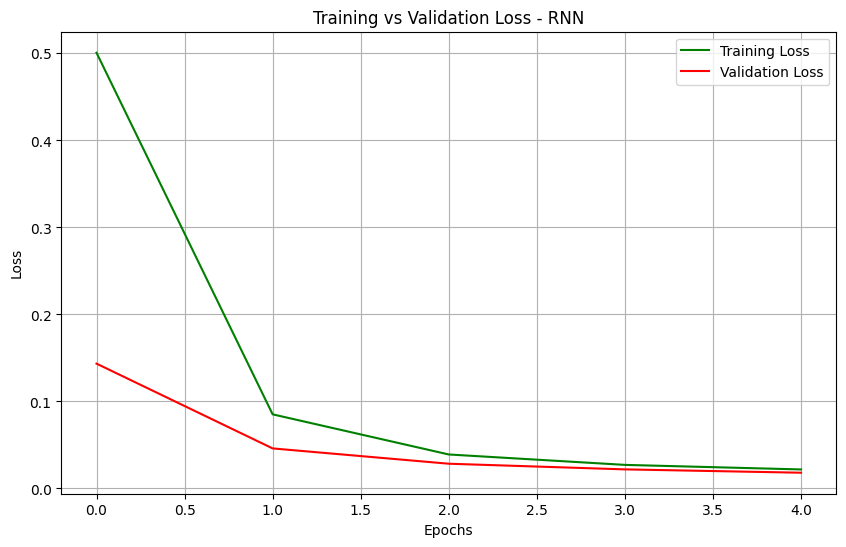

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history_rnn.history['loss'], label='Training Loss', color='green')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training vs Validation Loss - RNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
from sklearn.metrics import classification_report
import numpy as np


test_loss, test_accuracy = model_rnn.evaluate(X_test_pad, y_test_cat, verbose=1)
print(f"\nTest Accuracy (RNN): {test_accuracy:.4f}")
print(f"Test Loss (RNN): {test_loss:.4f}")

y_pred_probs = model_rnn.predict(X_test_pad)


y_pred_indices = np.argmax(y_pred_probs, axis=-1)
y_true_indices = np.argmax(y_test_cat, axis=-1)


y_pred_tags = [[label_encoder.inverse_transform([idx])[0] for idx in row] for row in y_pred_indices]
y_true_tags = [[label_encoder.inverse_transform([idx])[0] for idx in row] for row in y_true_indices]


y_pred_flat = []
y_true_flat = []

for true_seq, pred_seq, input_seq in zip(y_true_tags, y_pred_tags, X_test_pad):
    for true_tag, pred_tag, token in zip(true_seq, pred_seq, input_seq):
        if token != 0:
            y_true_flat.append(true_tag)
            y_pred_flat.append(pred_tag)


print("\nClassification Report (RNN):")
print(classification_report(y_true_flat, y_pred_flat, digits=4))


150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9885 - loss: 0.0418

Test Accuracy (RNN): 0.9882
Test Loss (RNN): 0.0429
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step

Classification Report (RNN):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          CC     0.9958    0.9933    0.9946      2403
          CD     0.9932    0.9422    0.9670      2476
          DT     0.9945    0.9954    0.9949      9928
          EX     0.8451    0.9836    0.9091        61
          IN     0.9824    0.9877    0.9850     12229
          JJ     0.9125    0.9058    0.9091      7783
         JJR     0.9028    0.9353    0.9187       278
         JJS     0.9161    0.9365    0.9262       315
         LRB     1.0000    0.9733    0.9865        75
          MD     0.9956    0.9941    0.9948       679
          NN     0.9487    0.9530    0.9509     14632
         NNP     0.9580    0.9530    0.9555     13127
        NNPS     0.8744    0.7121    0.7850       264
         NNS     0.9318    0.9674    0.9493      7557
         PDT     0.0000    0.0000    0.0000        18
         POS     0.9956    0.9982    0.9969      1122
         PRP     0.9977    0.9916    0.9946      1304
        PRP$     0.9847    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


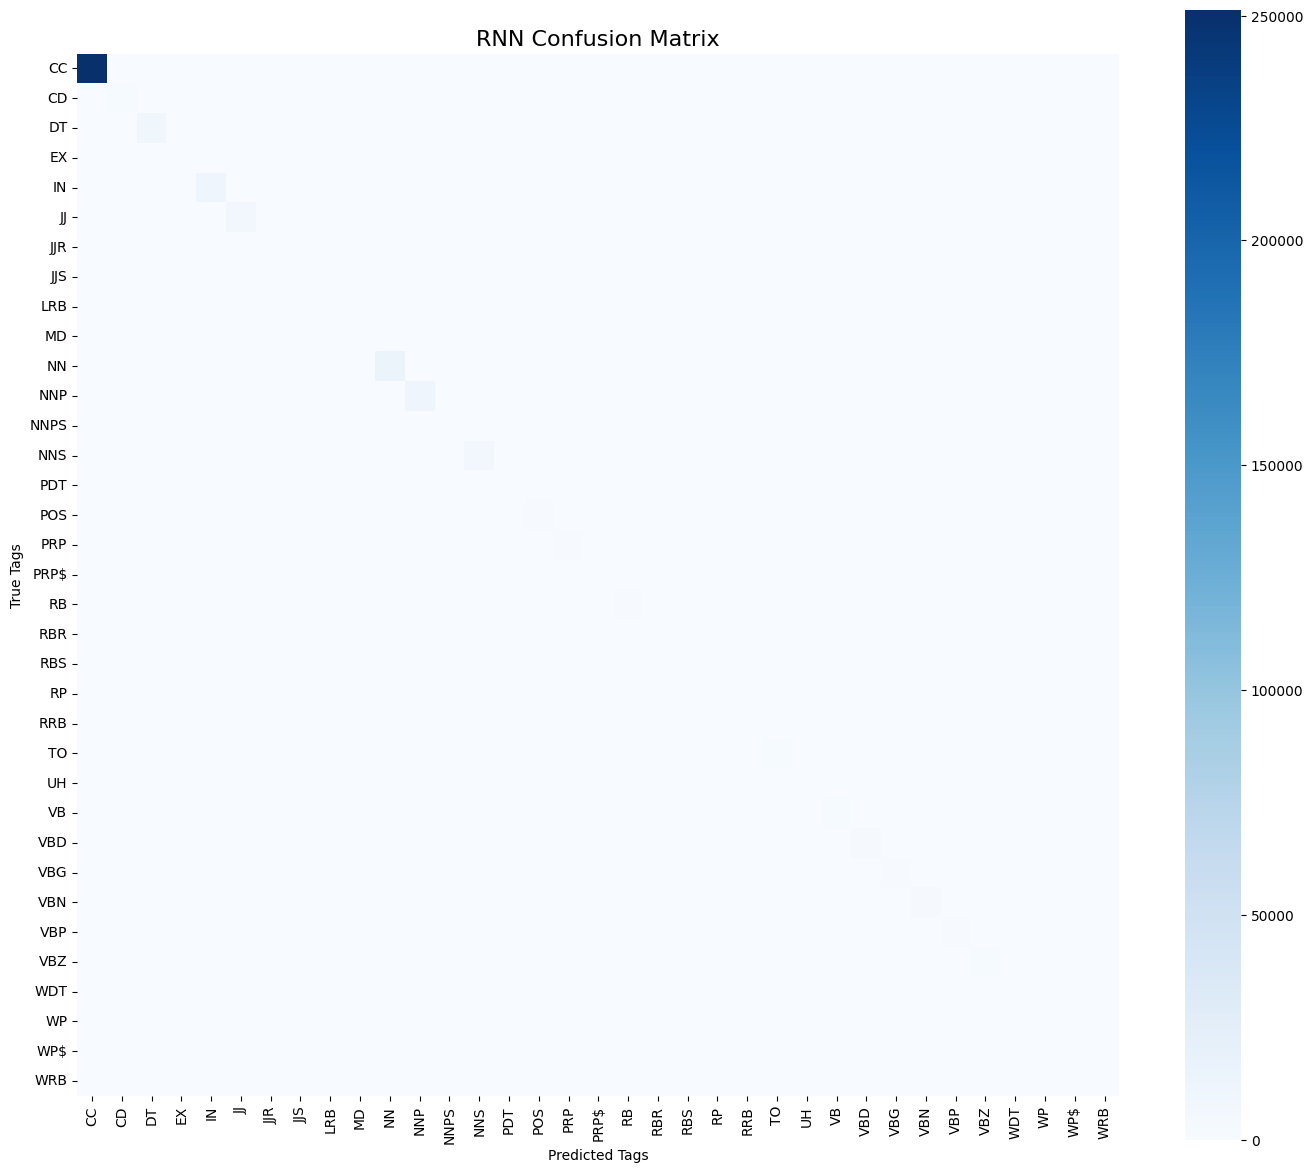

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_true_flat = [tag for sublist in y_true_tags for tag in sublist]
y_pred_flat = [tag for sublist in y_pred_tags for tag in sublist]


labels = np.unique(y_true_flat)

cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)


plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", fmt='g', square=True, cbar=True)
plt.title("RNN Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Tags")
plt.ylabel("True Tags")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


y_pred_flat = []
y_true_flat = []

for true_seq, pred_seq, input_seq in zip(y_true_tags, y_pred_tags, X_test_pad):
    for true_tag, pred_tag, token in zip(true_seq, pred_seq, input_seq):

        if token != 0:
            y_true_flat.append(true_tag)
            y_pred_flat.append(pred_tag)


overall_accuracy = accuracy_score(y_true_flat, y_pred_flat)

f1_macro = f1_score(y_true_flat, y_pred_flat, average='macro')
f1_weighted = f1_score(y_true_flat, y_pred_flat, average='weighted')

results_df = pd.DataFrame({
    "Model": ["RNN"],
    "Accuracy": [overall_accuracy],
    "F1 Macro": [f1_macro],
    "F1 Weighted": [f1_weighted]
})

print("\n RNN Evaluation Summary:")
print(results_df)



 RNN Evaluation Summary:
  Model  Accuracy  F1 Macro  F1 Weighted
0   RNN  0.957852  0.869844     0.957634


# LSTM Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam


embedding_dim = 128
lstm_units = 64
learning_rate = 0.001
batch_size = 64
epochs = 5


model_lstm = Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(input_dim=word_vocab_size, output_dim=embedding_dim),
    LSTM(units=lstm_units, return_sequences=True),
    TimeDistributed(Dense(pos_vocab_size, activation='softmax'))
])

optimizer = Adam(learning_rate=learning_rate)
model_lstm.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


model_lstm.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 72, 128)        │     2,941,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 72, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 72, 36)         │         2,340 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,992,932 (11.42 MB)

 Trainable params: 2,992,932 (11.42 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:

history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_train_pad, y_train_cat),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)


Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.7830 - loss: 0.9593 - val_accuracy: 0.9624 - val_loss: 0.1848
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9735 - loss: 0.1343 - val_accuracy: 0.9895 - val_loss: 0.0556
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9897 - loss: 0.0514 - val_accuracy: 0.9928 - val_loss: 0.0339
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9927 - loss: 0.0334 - val_accuracy: 0.9939 - val_loss: 0.0259
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9940 - loss: 0.0249 - val_accuracy: 0.9947 - val_loss: 0.0216


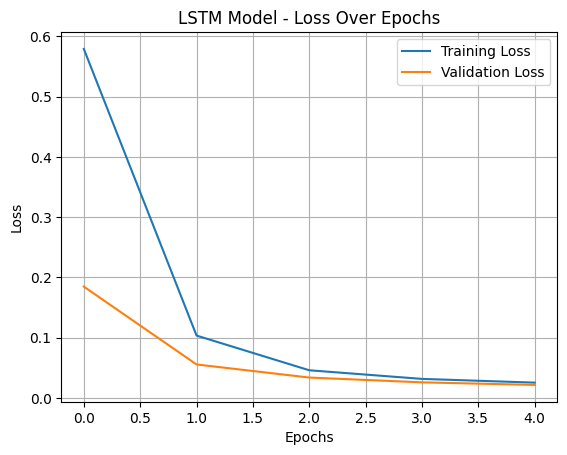

In [29]:
import matplotlib.pyplot as plt


plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model - Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [30]:

test_loss, test_accuracy = model_lstm.evaluate(X_test_pad, y_test_cat, verbose=1)

print(f"\n Test Accuracy (LSTM): {test_accuracy:.4f}")
print(f" Test Loss: {test_loss:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9885 - loss: 0.0422

 Test Accuracy (LSTM): 0.9883
 Test Loss: 0.0432


In [31]:
import numpy as np


y_pred_lstm_probs = model_lstm.predict(X_test_pad)

y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=-1)
y_true_lstm = np.argmax(y_test_cat, axis=-1)


y_pred_tags = [[label_encoder.inverse_transform([idx])[0] for idx in row] for row in y_pred_lstm]
y_true_tags = [[label_encoder.inverse_transform([idx])[0] for idx in row] for row in y_true_lstm]



y_pred_flat = []
y_true_flat = []

for true_seq, pred_seq, mask in zip(y_true_tags, y_pred_tags, X_test_pad):
    for true_tag, pred_tag, token in zip(true_seq, pred_seq, mask):
        if token != 0:
            y_true_flat.append(true_tag)
            y_pred_flat.append(pred_tag)

150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [32]:
from sklearn.metrics import classification_report, f1_score


print(" Classification Report (LSTM):")
print(classification_report(y_true_flat, y_pred_flat, digits=4))

macro_f1 = f1_score(y_true_flat, y_pred_flat, average='macro')
weighted_f1 = f1_score(y_true_flat, y_pred_flat, average='weighted')

print(f"\n Macro F1 Score (LSTM): {macro_f1:.4f}")
print(f" Weighted F1 Score (LSTM): {weighted_f1:.4f}")


 Classification Report (LSTM):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          CC     0.9958    0.9929    0.9944      2403
          CD     0.9949    0.9398    0.9666      2476
          DT     0.9952    0.9954    0.9953      9928
          EX     0.7895    0.9836    0.8759        61
          IN     0.9838    0.9854    0.9846     12229
          JJ     0.8991    0.9120    0.9055      7783
         JJR     0.8933    0.9640    0.9273       278
         JJS     0.9127    0.9619    0.9366       315
         LRB     0.9865    0.9733    0.9799        75
          MD     0.9956    0.9941    0.9948       679
          NN     0.9470    0.9517    0.9493     14632
         NNP     0.9435    0.9679    0.9556     13127
        NNPS     0.8435    0.7348    0.7854       264
         NNS     0.9763    0.9534    0.9647      7557
         PDT     0.0000    0.0000    0.0000        18
         POS     0.9947    0.9982    0.9964      1122
         PRP     0.9985    0.9908    0.9946      1304
        PRP$     0.9882    

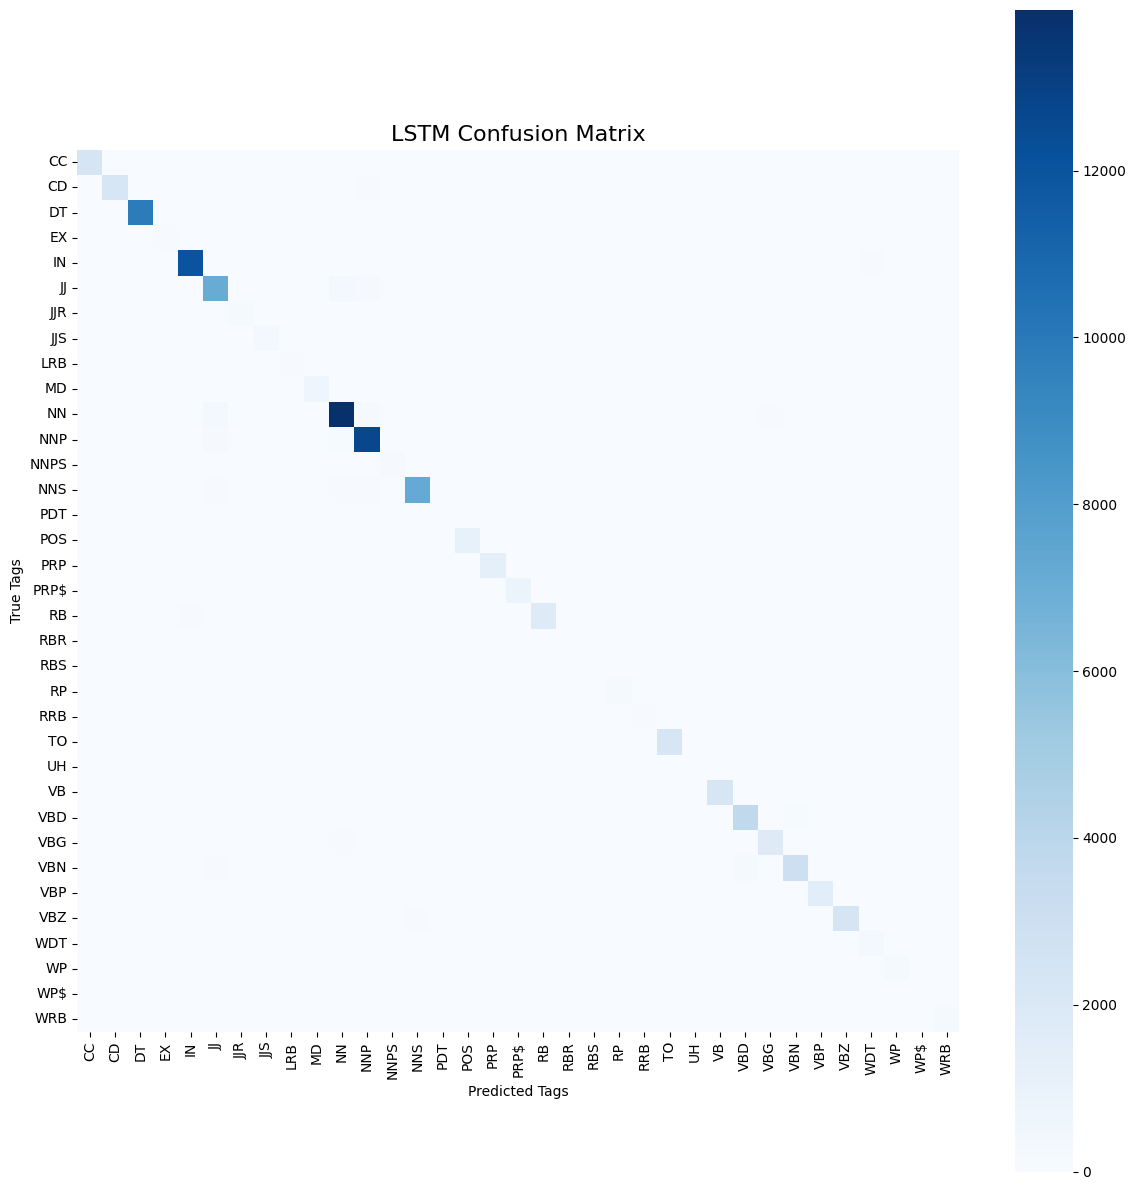

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


labels = np.unique(y_true_tags)
cm = confusion_matrix(y_true_flat, y_pred_flat)

plt.figure(figsize=(12,12))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", fmt='g', square=True, cbar=True)
plt.title("LSTM Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Tags")
plt.ylabel("True Tags")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# GRU Model

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam



embedding_dim = 128
gru_units = 64
learning_rate = 0.001
batch_size = 64
epochs = 5

model_gru = Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(input_dim=word_vocab_size, output_dim=embedding_dim),
    GRU(units=gru_units, return_sequences=True),
    TimeDistributed(Dense(pos_vocab_size, activation='softmax'))
])



optimizer = Adam(learning_rate=learning_rate)
model_gru.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])



model_gru.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 72, 128)        │     2,941,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 72, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 72, 36)         │         2,340 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,980,772 (11.37 MB)

 Trainable params: 2,980,772 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:

history_gru = model_gru.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_train_pad, y_train_cat),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8378 - loss: 0.8390 - val_accuracy: 0.9818 - val_loss: 0.0956
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9845 - loss: 0.0768 - val_accuracy: 0.9913 - val_loss: 0.0394
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9915 - loss: 0.0375 - val_accuracy: 0.9933 - val_loss: 0.0273
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9931 - loss: 0.0273 - val_accuracy: 0.9943 - val_loss: 0.0223
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9941 - loss: 0.0221 - val_accuracy: 0.9949 - val_loss: 0.0193


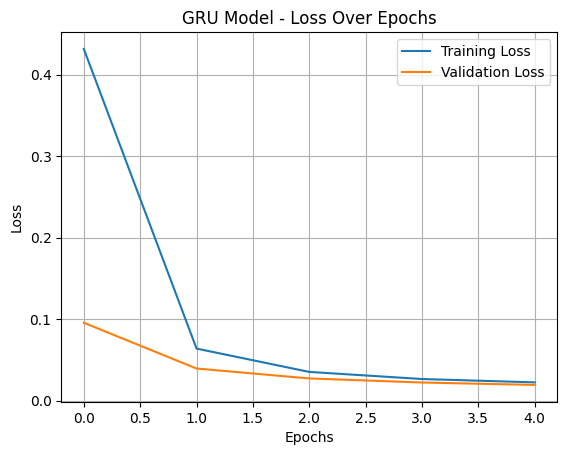

In [36]:
import matplotlib.pyplot as plt


plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model - Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [37]:

loss_gru, accuracy_gru = model_gru.evaluate(X_test_pad, y_test_cat)
print(f"\n Test Accuracy (GRU): {accuracy_gru:.4f}")
print(f" Test Loss: {loss_gru:.4f}")


150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9886 - loss: 0.0411

 Test Accuracy (GRU): 0.9884
 Test Loss: 0.0423


150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

 Classification Report (GRU):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score        support
CC             0.999960  0.999936  0.999948  251363.000000
CD             0.997422  0.937399  0.966479    2476.000000
DT             0.994666  0.995568  0.995117    9928.000000
EX             0.810811  0.983607  0.888889      61.000000
IN             0.984636  0.985199  0.984917   12229.000000
JJ             0.928210  0.895413  0.911517    7783.000000
JJR            0.899666  0.967626  0.932409     278.000000
JJS            0.973684  0.939683  0.956381     315.000000
LRB            1.000000  0.973333  0.986486      75.000000
MD             0.995575  0.994109  0.994842     679.000000
NN             0.923572  0.961318  0.942067   14632.000000
NNP            0.939234  0.961987  0.950474   13127.000000
NNPS           0.861472  0.753788  0.804040     264.000000
NNS            0.980803  0.953288  0.966850    7557.000000
PDT            0.000000  0.000000  0.000000      18.000000
POS            0.995556  0.998217  0.996885    1122.0000

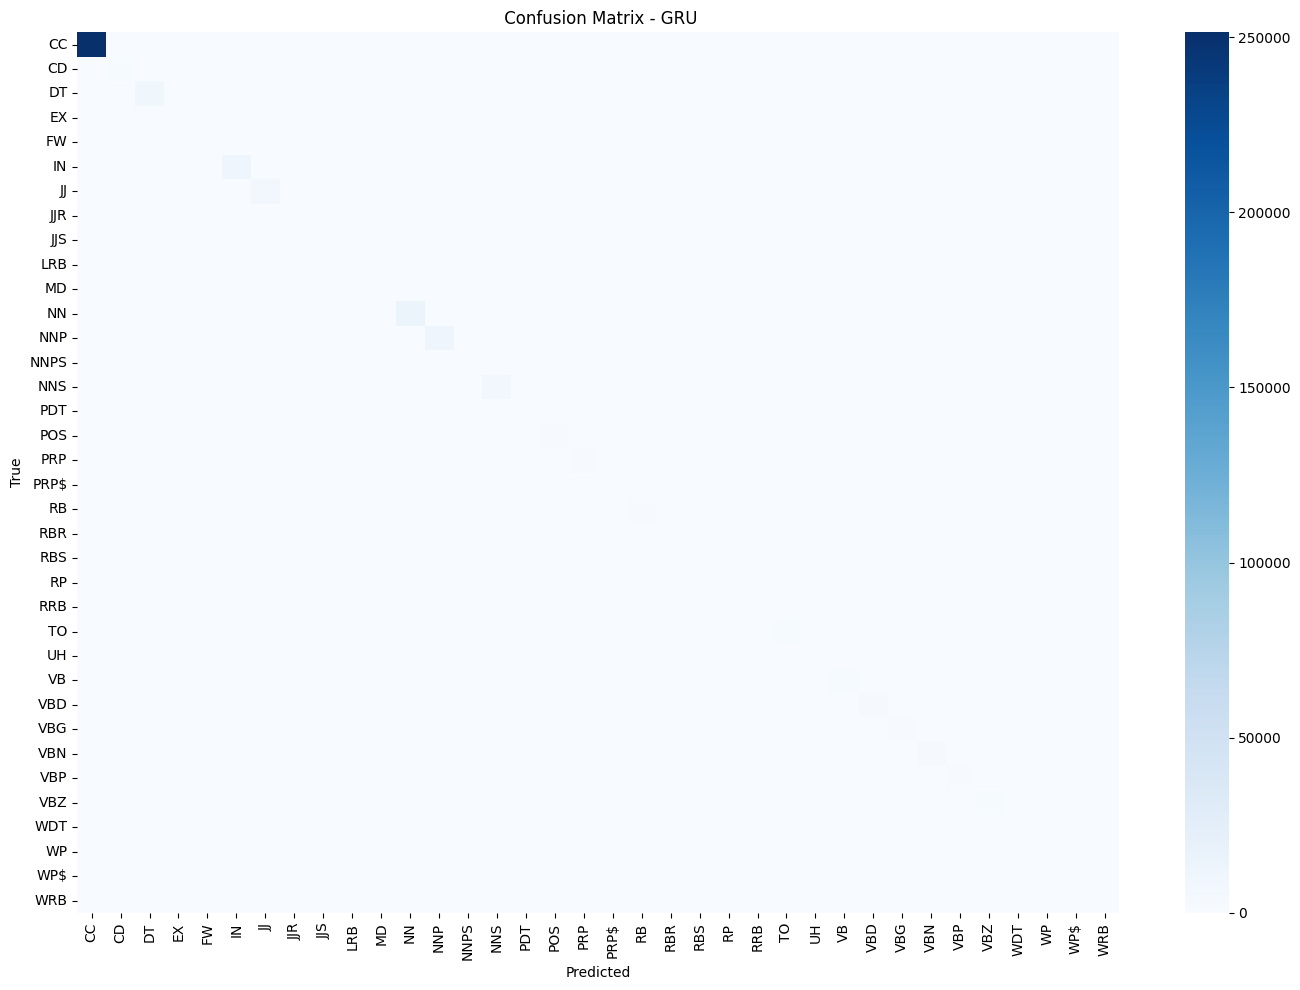

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_pred_gru_probs = model_gru.predict(X_test_pad)
y_pred_gru = np.argmax(y_pred_gru_probs, axis=-1)
y_true_gru = np.argmax(y_test_cat, axis=-1)

y_pred_tags = [[label_encoder.classes_[idx] for idx in row] for row in y_pred_gru]
y_true_tags = [[label_encoder.classes_[idx] for idx in row] for row in y_true_gru]


y_pred_flat = [tag for row in y_pred_tags for tag in row]
y_true_flat = [tag for row in y_true_tags for tag in row]

print("\n Classification Report (GRU):")
report_gru = classification_report(y_true_flat, y_pred_flat, digits=4, output_dict=True)
report_gru_df = pd.DataFrame(report_gru).transpose()
print(report_gru_df)


f1_macro = f1_score(y_true_flat, y_pred_flat, average='macro')
f1_weighted = f1_score(y_true_flat, y_pred_flat, average='weighted')
print(f"\n Macro F1-score (GRU): {f1_macro:.4f}")
print(f" Weighted F1-score (GRU): {f1_weighted:.4f}")


cm_gru = confusion_matrix(y_true_flat, y_pred_flat, labels=label_encoder.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_gru, annot=False, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
plt.title(" Confusion Matrix - GRU")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# BiLSTM Model

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam


embedding_dim = 128
lstm_units = 64
learning_rate = 0.001
batch_size = 64
epochs = 5


model_bilstm = Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(input_dim=word_vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(units=lstm_units, return_sequences=True)),
    TimeDistributed(Dense(pos_vocab_size, activation='softmax'))
])

optimizer = Adam(learning_rate=learning_rate)
model_bilstm.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model_bilstm.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 72, 128)        │     2,941,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 72, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 72, 36)         │         4,644 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044,644 (11.61 MB)

 Trainable params: 3,044,644 (11.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_train_pad, y_train_cat),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.7989 - loss: 0.8499 - val_accuracy: 0.9763 - val_loss: 0.1116
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9822 - loss: 0.0820 - val_accuracy: 0.9926 - val_loss: 0.0350
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9931 - loss: 0.0311 - val_accuracy: 0.9951 - val_loss: 0.0219
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9951 - loss: 0.0213 - val_accuracy: 0.9964 - val_loss: 0.0166
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9961 - loss: 0.0175 - val_accuracy: 0.9970 - val_loss: 0.0136


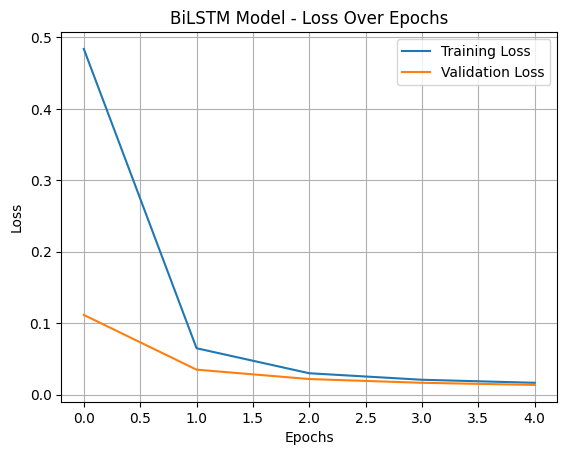

In [41]:
import matplotlib.pyplot as plt
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Model - Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
test_loss_bilstm, test_accuracy_bilstm = model_bilstm.evaluate(X_test_pad, y_test_cat)
print(f"\nTest Accuracy (BiLSTM): {test_accuracy_bilstm:.4f}")
print(f"Test Loss: {test_loss_bilstm:.4f}")


150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9911 - loss: 0.0332

Test Accuracy (BiLSTM): 0.9911
Test Loss: 0.0339


150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
 Classification Report (BiLSTM):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          CC     0.9962    0.9929    0.9946      2403
          CD     0.9953    0.9414    0.9676      2476
          DT     0.9954    0.9950    0.9952      9928
          EX     0.9231    0.9836    0.9524        61
          IN     0.9911    0.9893    0.9902     12229
          JJ     0.9233    0.9483    0.9357      7783
         JJR     0.9412    0.9209    0.9309       278
         JJS     0.9838    0.9651    0.9744       315
         LRB     1.0000    0.9733    0.9865        75
          MD     0.9971    0.9956    0.9963       679
          NN     0.9552    0.9636    0.9594     14632
         NNP     0.9642    0.9653    0.9647     13127
        NNPS     0.8865    0.7689    0.8235       264
         NNS     0.9692    0.9674    0.9683      7557
         PDT     1.0000    0.1111    0.2000        18
         POS     0.9956    0.9982    0.9969      1122
         PRP     0.9985    0.9931    0.9958      1304
        PRP$     0.9905    

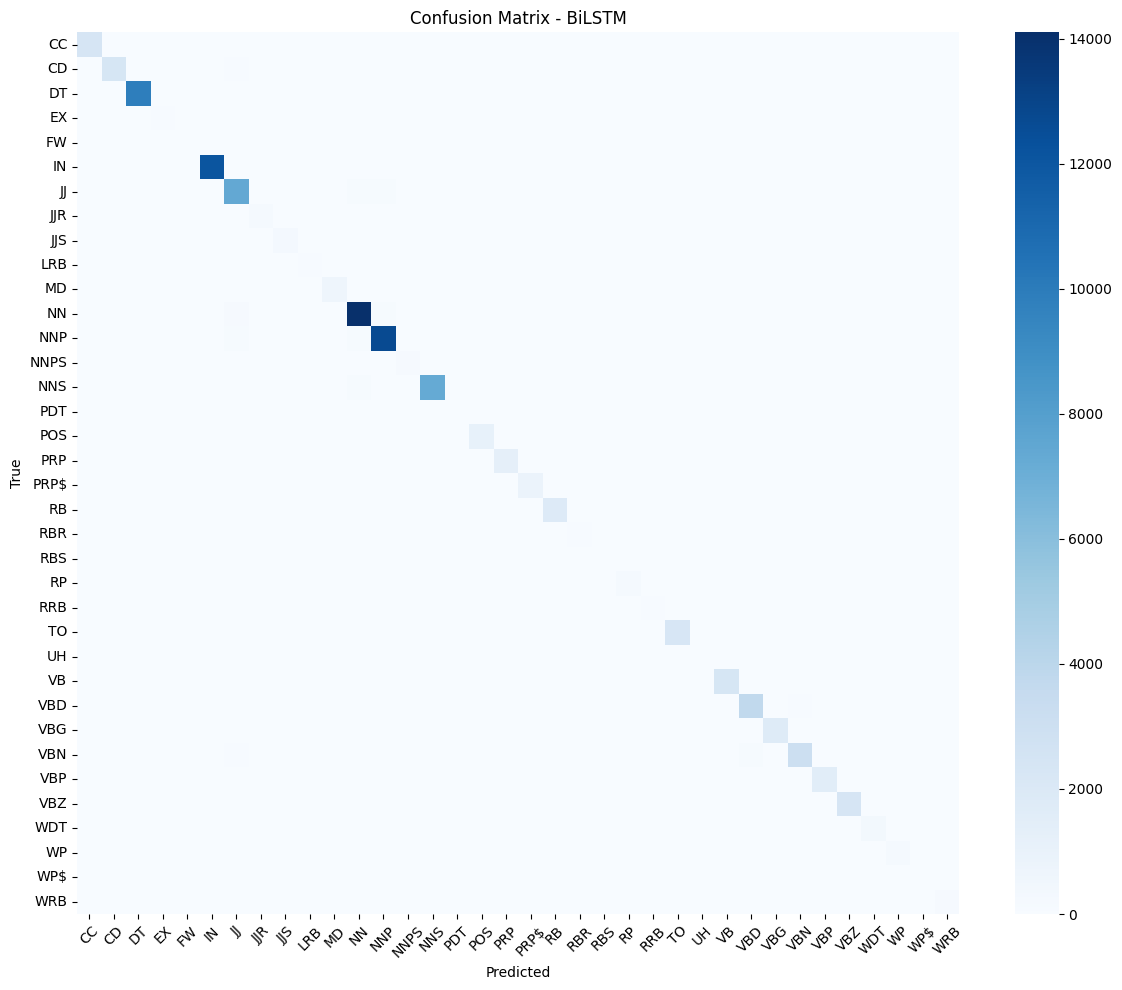

In [43]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_pred_bilstm = model_bilstm.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_pred_bilstm, axis=-1)
y_true_bilstm = np.argmax(y_test_cat, axis=-1)


y_pred_flat = []
y_true_flat = []


test_sentences_pad = X_test_pad

for i in range(len(y_true_bilstm)):
    for j in range(len(y_true_bilstm[i])):
        if test_sentences_pad[i][j] != 0:
            y_pred_flat.append(y_pred_bilstm[i][j])
            y_true_flat.append(y_true_bilstm[i][j])


y_pred_tags = label_encoder.inverse_transform(y_pred_flat)
y_true_tags = label_encoder.inverse_transform(y_true_flat)


print(" Classification Report (BiLSTM):")
print(classification_report(y_true_tags, y_pred_tags, digits=4))


f1_macro = f1_score(y_true_tags, y_pred_tags, average='macro')
f1_weighted = f1_score(y_true_tags, y_pred_tags, average='weighted')

print(f"\n BiLSTM F1-Score (Macro): {f1_macro:.4f}")
print(f" BiLSTM F1-Score (Weighted): {f1_weighted:.4f}")


cm = confusion_matrix(y_true_tags, y_pred_tags, labels=label_encoder.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Comparison Table

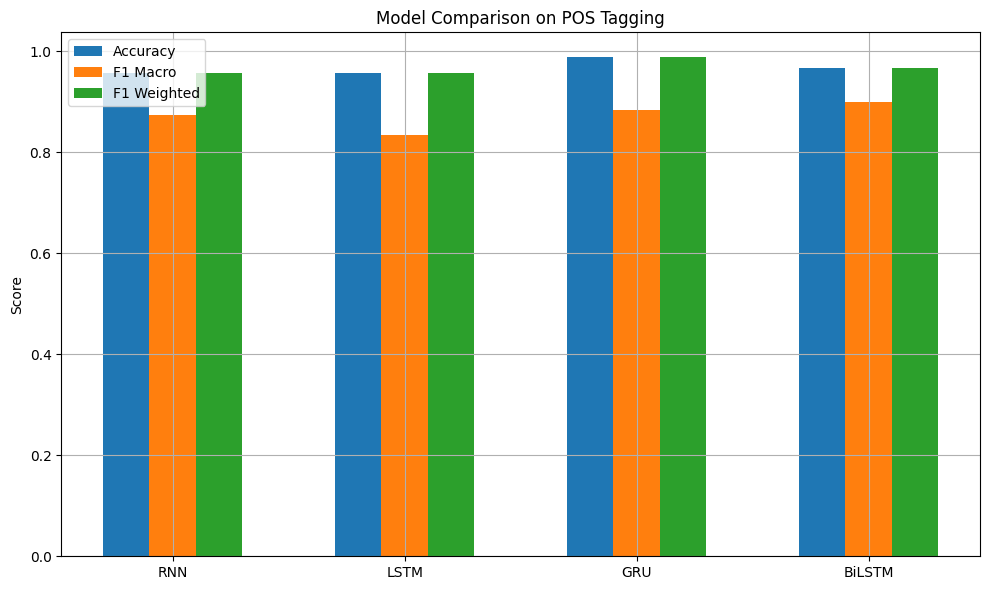

In [44]:
import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'GRU', 'BiLSTM']
accuracy = [0.9569, 0.9575, 0.9881, 0.9674]
f1_macro = [0.8748, 0.8347, 0.8841, 0.8989]
f1_weighted = [0.9567, 0.9574, 0.9882, 0.9674]

x = range(len(models))
plt.figure(figsize=(10,6))
plt.bar(x, accuracy, width=0.2, label='Accuracy')
plt.bar([p + 0.2 for p in x], f1_macro, width=0.2, label='F1 Macro')
plt.bar([p + 0.4 for p in x], f1_weighted, width=0.2, label='F1 Weighted')

plt.xticks([p + 0.2 for p in x], models)
plt.ylabel("Score")
plt.title("Model Comparison on POS Tagging")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [45]:
import pandas as pd

model_names = ['RNN', 'LSTM', 'GRU', 'BiLSTM']
accuracy = [0.9569, 0.9575, 0.9881, 0.9674]
f1_macro = [0.8748, 0.8347, 0.8841, 0.8989]
f1_weighted = [0.9567, 0.9574, 0.9882, 0.9674]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': accuracy,
    'F1-Score (Macro)': f1_macro,
    'F1-Score (Weighted)': f1_weighted
})

print("\n Model Comparison Table:")
print(comparison_df.to_string(index=False))



 Model Comparison Table:
 Model  Test Accuracy  F1-Score (Macro)  F1-Score (Weighted)
   RNN         0.9569            0.8748               0.9567
  LSTM         0.9575            0.8347               0.9574
   GRU         0.9881            0.8841               0.9882
BiLSTM         0.9674            0.8989               0.9674


# Hyperparameter tuning

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

learning_rates = [0.001, 0.005]
batch_sizes = [32, 64]
rnn_units = [64, 128]
epochs = 5

results = []

X_train_input = X_train_pad
train_labels_pad = y_train_pad
y_train_input = to_categorical(train_labels_pad, num_classes=pos_vocab_size)

model_types = ['RNN', 'LSTM', 'GRU', 'BiLSTM']

for model_type in model_types:
    for lr in learning_rates:
        for bs in batch_sizes:
            for units in rnn_units:
                print(f"\nTraining {model_type} with lr={lr}, batch_size={bs}, units={units}")

                model = Sequential()
                model.add(Embedding(input_dim=word_vocab_size, output_dim=128))

                if model_type == 'RNN':
                    model.add(SimpleRNN(units=units, return_sequences=True))
                elif model_type == 'LSTM':
                    model.add(LSTM(units=units, return_sequences=True))
                elif model_type == 'GRU':
                    model.add(GRU(units=units, return_sequences=True))
                elif model_type == 'BiLSTM':
                    model.add(Bidirectional(LSTM(units=units, return_sequences=True)))

                model.add(TimeDistributed(Dense(pos_vocab_size, activation='softmax')))

                model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

                history = model.fit(
                    X_train_input, y_train_input,
                    validation_data=(X_train_pad, y_train_cat),
                    batch_size=bs,
                    epochs=epochs,
                    verbose=1
                )

                best_val_acc = max(history.history['val_accuracy'])

                results.append({
                    'Model': model_type,
                    'Learning Rate': lr,
                    'Batch Size': bs,
                    'Units': units,
                    'Best Val Accuracy': best_val_acc
                })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='Best Val Accuracy', ascending=False)

print("\n Top Hyperparameter Configurations by Validation Accuracy")
print(results_df.head(10))


Training RNN with lr=0.001, batch_size=32, units=64
Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.8554 - loss: 0.6932 - val_accuracy: 0.9874 - val_loss: 0.0628
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9893 - loss: 0.0506 - val_accuracy: 0.9936 - val_loss: 0.0269
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9936 - loss: 0.0260 - val_accuracy: 0.9950 - val_loss: 0.0197
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9951 - loss: 0.0189 - val_accuracy: 0.9960 - val_loss: 0.0157
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9958 - loss: 0.0163 - val_accuracy: 0.9968 - val_loss: 0.0127

Training RNN with lr=0.001, batch_size=32, units=128
Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.8641 - loss: 0.5923 - val_accuracy: 0.9901 - val_loss: 0.0456
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9905 - loss: 0.0416 - val_accuracy: 0.9944 - val_loss: 0.

In [67]:
if 'results_df' in locals() and len(results_df) > 0:

    print("\nBest Hyperparameter Configuration for Each Model\n")

    model_order = ['RNN', 'LSTM', 'GRU', 'BiLSTM']

    for model in model_order:
        model_results = results_df[results_df['Model'] == model]

        if len(model_results) > 0:
            best_row = model_results.loc[model_results['Best Val Accuracy'].idxmax()]

            print(f"Best {model} Model Results")
            print(f"Best Validation Accuracy: {best_row['Best Val Accuracy']:.6f}")
            print(f"Learning Rate: {best_row['Learning Rate']}")
            print(f"Batch Size: {best_row['Batch Size']}")
            print(f"Units: {best_row['Units']}")
            print("-" * 50)

        else:
            print(f"No results found for {model}")

else:
    print("No results found. Please ensure the hyperparameter tuning loop has finished running.")


Best Hyperparameter Configuration for Each Model

Best RNN Model Results
Best Validation Accuracy: 0.998331
Learning Rate: 0.005
Batch Size: 64
Units: 128
--------------------------------------------------
Best LSTM Model Results
Best Validation Accuracy: 0.997117
Learning Rate: 0.005
Batch Size: 32
Units: 64
--------------------------------------------------
Best GRU Model Results
Best Validation Accuracy: 0.996881
Learning Rate: 0.005
Batch Size: 64
Units: 128
--------------------------------------------------
Best BiLSTM Model Results
Best Validation Accuracy: 0.999112
Learning Rate: 0.005
Batch Size: 32
Units: 64
--------------------------------------------------


In [68]:
best_models.to_csv("best_model_hyperparameters.csv", index=False)

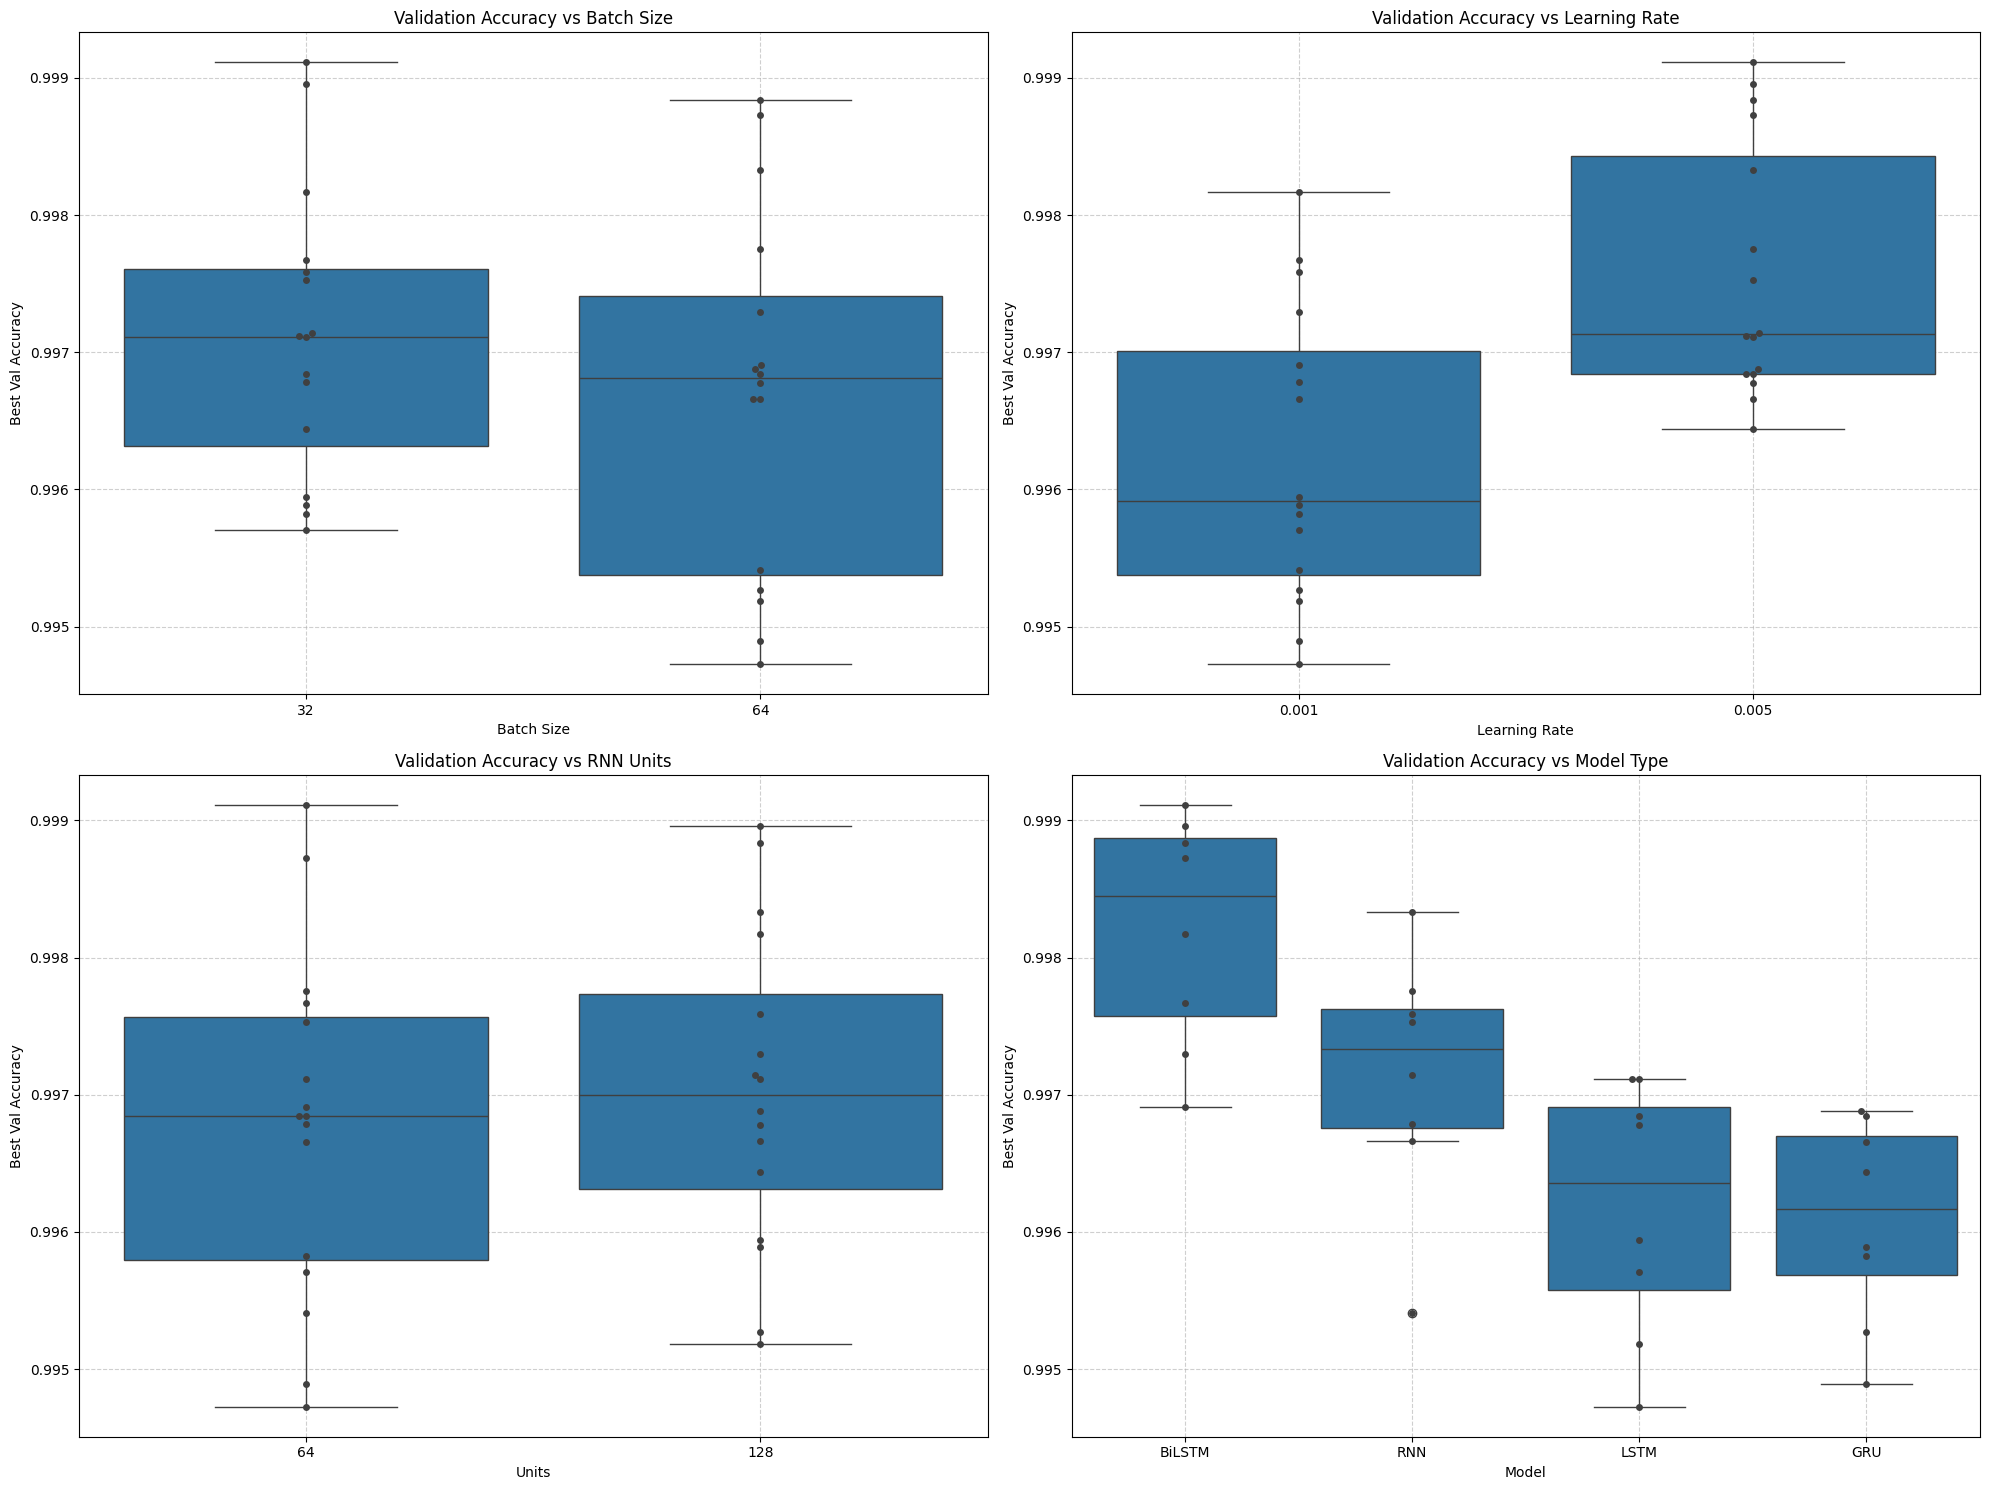

/tmp/ipykernel_3252/357123272.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Model', y='Best Val Accuracy', data=df, ci=None)


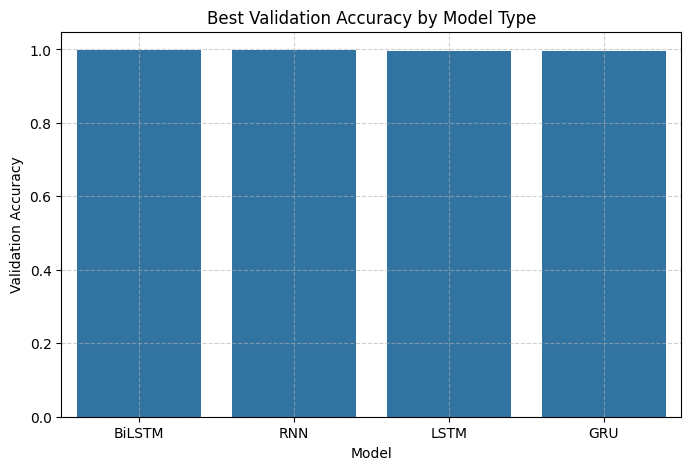

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'results_df' in locals() and len(results_df) > 0:

    df = results_df.copy()

    plt.figure(figsize=(20, 15))

    metrics = ['Batch Size', 'Learning Rate', 'Units']
    titles = ['Batch Size', 'Learning Rate', 'RNN Units']

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        plt.subplot(2, 2, i+1)

        sns.boxplot(x=metric, y='Best Val Accuracy', data=df)
        sns.swarmplot(x=metric, y='Best Val Accuracy', data=df, color=".25")

        plt.title(f'Validation Accuracy vs {title}')
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(2, 2, 4)
    sns.boxplot(x='Model', y='Best Val Accuracy', data=df)
    sns.swarmplot(x='Model', y='Best Val Accuracy', data=df, color=".25")

    plt.title('Validation Accuracy vs Model Type')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

else:
    print("No results to plot. Please run the hyperparameter tuning first.")

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Best Val Accuracy', data=df, ci=None)
plt.title("Best Validation Accuracy by Model Type")
plt.ylabel("Validation Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [76]:
model_order = ['RNN', 'LSTM', 'GRU', 'BiLSTM']

best_configs = {}

for model_name in model_order:
    model_df = results_df[results_df['Model'] == model_name]
    if not model_df.empty:
        best_row = model_df.loc[model_df['Best Val Accuracy'].idxmax()]
        best_configs[model_name] = best_row

histories = {}

for model_type in model_order:
    if model_type not in best_configs:
        continue

    config = best_configs[model_type]


    lr = float(config['Learning Rate'])
    bs = int(config['Batch Size'])
    units = int(config['Units'])

    print(f"\nRetraining Best {model_type} Model with lr={lr}, bs={bs}, units={units}...")

    model = Sequential()
    model.add(Embedding(input_dim=word_vocab_size, output_dim=128))

    if model_type == 'RNN':
        model.add(SimpleRNN(units=units, return_sequences=True))
    elif model_type == 'LSTM':
        model.add(LSTM(units=units, return_sequences=True))
    elif model_type == 'GRU':
        model.add(GRU(units=units, return_sequences=True))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units=units, return_sequences=True)))

    model.add(TimeDistributed(Dense(pos_vocab_size, activation='softmax')))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_train_pad, y_train_cat),
        batch_size=bs,
        epochs=epochs,
        verbose=1
    )

    histories[model_type] = history


Retraining Best RNN Model with lr=0.005, bs=64, units=128...
Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.8934 - loss: 0.4510 - val_accuracy: 0.9929 - val_loss: 0.0273
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9930 - loss: 0.0262 - val_accuracy: 0.9954 - val_loss: 0.0164
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.9970 - val_loss: 0.0110
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9969 - loss: 0.0113 - val_accuracy: 0.9977 - val_loss: 0.0083
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9977 - loss: 0.0084 - val_accuracy: 0.9983 - val_loss: 0.0060

Retraining Best LSTM Model with lr=0.005, bs=32, units=64...
Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9017 - loss: 0.4103 - val_accuracy: 0.9928 - val_loss: 0.0271
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.9927 - loss: 0.0263 - val_accuracy: 0.

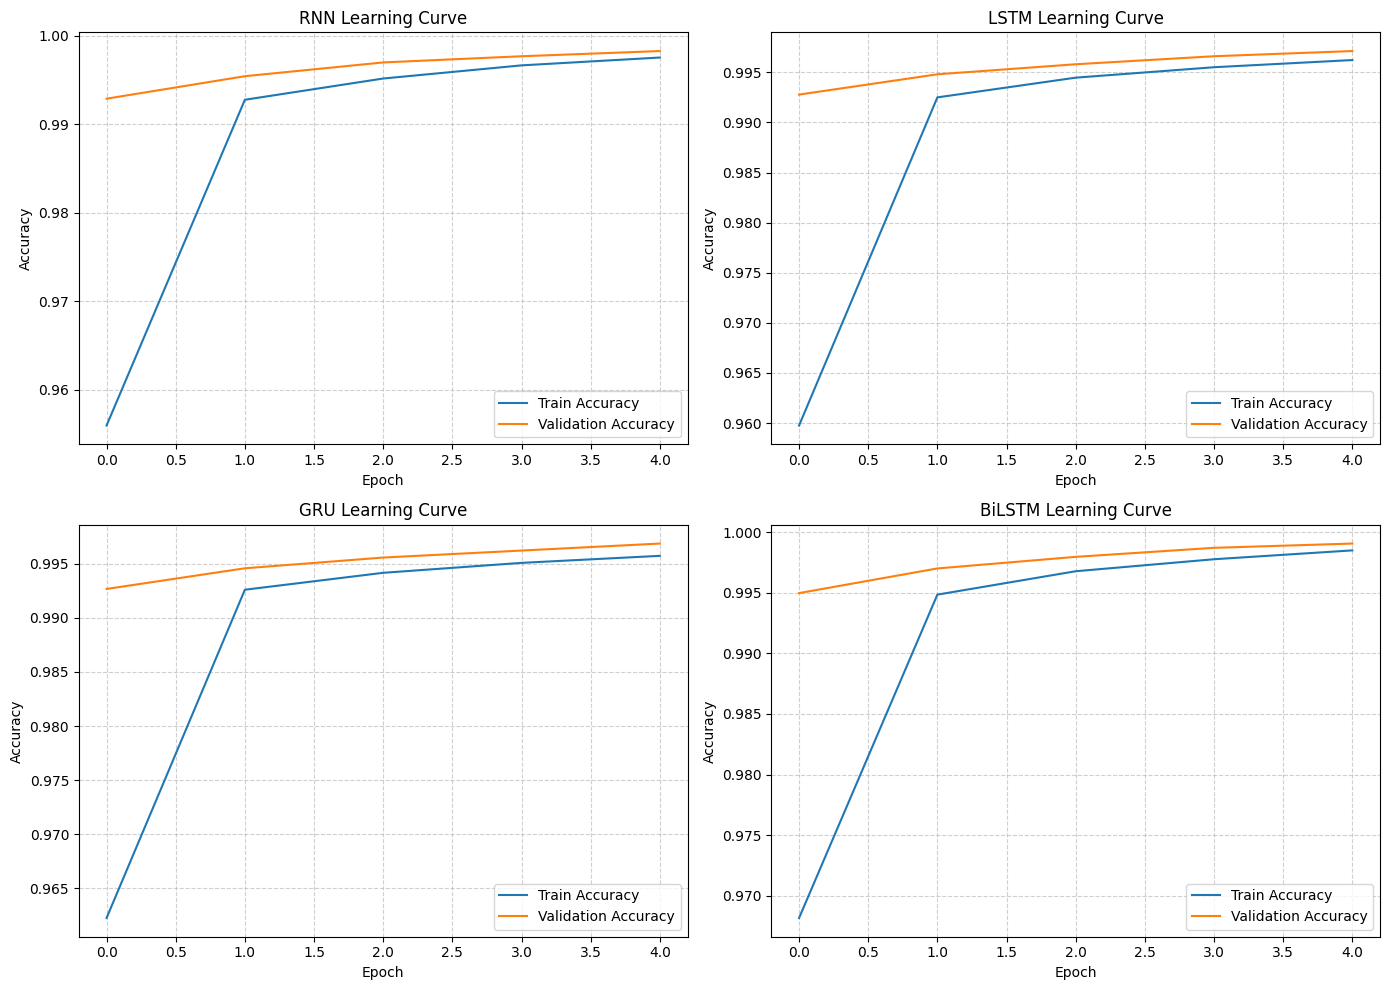

In [77]:
plt.figure(figsize=(14,10))

for i, model_type in enumerate(model_order):

    plt.subplot(2,2,i+1)

    history = histories[model_type]

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{model_type} Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

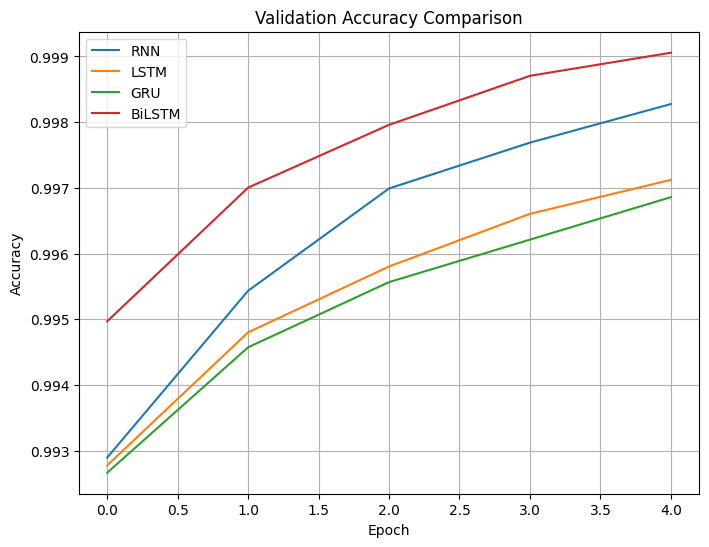

In [78]:
plt.figure(figsize=(8,6))

for model_type in model_order:
    plt.plot(histories[model_type].history['val_accuracy'], label=model_type)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()